In [ ]:
import re

import ftfy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet



In [105]:
TARGET_CLASSES = ['Depression', 'Suicidal', 'Normal', 'Joy', 'Stress', 'Anxiety']
CAP_PER_CLASS  = 20000

MENTAL_HEALTH_PATH      = '../data/raw/Combined Data.csv'
SUICIDE_PATH            = '../data/raw/Suicide_Detection.csv'
EMOTIONS_TRAIN_PATH     = '../data/raw/emotions_nlp_train.txt'
EMOTIONS_VAL_PATH       = '../data/raw/emotions_nlp_val.txt'
EMOTIONS_TEST_PATH      = '../data/raw/emotions_nlp_test.txt'
EMOTIONS_CSV_PATH       = '../data/raw/emotions.csv'
EMOTION_V5_PATH         = '../data/raw/emotion_dataset_v5_clean.csv'
DAILYDIALOG_PATH        = '../data/raw/DailyDialog.csv'
TWITTER_TRAIN_PATH      = '../data/raw/twitter_training.csv'
TWITTER_VAL_PATH        = '../data/raw/twitter_validation.csv'
TWITTER_TEST_PATH       = '../data/raw/twitter_test.csv'
CANCER_PATH             = '../data/raw/cancer_mental_health.csv'
FEATURE_ENGINEERED_PATH = '../data/raw/mental_heath_feature_engineered.csv'

OUTPUT_LABELED_PATH = '../data/processed/cancer mental health final.csv'
OUTPUT_VOCAB_PATH   = '../data/processed/cancer vocab text.csv'
MODEL_DIR           = '../models/'

print('Target classes:', TARGET_CLASSES)

Target classes: ['Depression', 'Suicidal', 'Normal', 'Joy', 'Stress', 'Anxiety']


# Color map for each emotion

In [106]:
COLOR_MAP = {
    'Depression': '#1f77b4',   
    'Suicidal': '#d62728',  
    'Normal': '#2ca02c',       
    'Joy': '#ffcc00',         
    'Stress': '#ff7f0e',       
    'Anxiety': '#9467bd'       
}


# Text cleaning functions

In [107]:
lemmatizer = WordNetLemmatizer()

def fix_encoding(text):
    if not isinstance(text, str):
        return text
    text = ftfy.fix_text(text)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]', '', text)
    text = re.sub(r' {2,}', ' ', text)
    return text.strip()

def quick_clean(df, text_col='text'):
    #Drop any nulls, clean text, and filter out very short posts
    df = df.dropna(subset=[text_col]).copy()
    df[text_col] = df[text_col].astype(str).apply(fix_encoding)
    df = df[df[text_col].str.split().str.len() >= 10]
    return df

def remove_patterns(text):
    text = str(text).lower()
    text = re.sub(r'http[s]?://\S+', '', text)
    text = re.sub(r'\[.*?\]\(.*?\)', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_map = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'R': wordnet.ADV}
    return tag_map.get(tag, wordnet.NOUN)

def lemmatize_text(text):
    tokens = word_tokenize(text)
    result = []
    for token in tokens:
        if not token.isalpha():
            continue
        pos   = get_wordnet_pos(token)
        lemma = lemmatizer.lemmatize(token, pos)
        result.append(lemma)
    return ' '.join(result)

## Emotion Lexicons

In [108]:
#These are predefined word sets which will be used to identify the specific emotional states in text
JOY_WORDS = {
    'happy','happiness','joy','joyful','excited','excitement','amazing','wonderful',
    'fantastic','great','love','loved','grateful','gratitude','blessed','thrilled',
    'delighted','ecstatic','overjoyed','proud','celebrate','celebrating','smiling',
    'laughing','laugh','beautiful','incredible','awesome','lucky','thankful',
    'promoted','promotion','scholarship','accepted','engaged','proposal','born',
    'baby','married','wedding','vacation','holiday','trip','surprise','gift',
    'moon','unstoppable','alive','peace','peaceful','magical','crossed','finish',
    'line','milestone','achievement','achieved','dream','worth','penny','saved',
    'cheering','dancing','danced','winning','won','passed','congratulations',
    'glowing','beaming','radiant','light','smile','grinning','grin','elated',
    'content','fulfilling','fulfilled','meaningful','rewarding','rewarded'
}

ANXIETY_WORDS = {
    'anxious','anxiety','worry','worried','worrying','panic','panicking','fear',
    'fearful','terrified','terrifying','terror','dread','dreading','nervous',
    'catastrophize','catastrophizing','overthink','overthinking','racing',
    'trembling','shaking','freeze','frozen','avoid','avoidance','scared',
    'breathe','chest','tightens','tighten','attacks','attack','scenarios',
    'convinced','wrong','shake','judged','highways','losing','control',
    'smaller','triggered','trigger','worrying','terrible','cancelled',
    'interviews','crowd','crowded','spiral','spiraling','restless','uneasy',
    'apprehensive','tense','tension','phobia','obsess','obsessing',
    'checking','locks','ruminate','ruminating','sleepless','insomnia',
    'heart','pounding','sweating','sweat','nauseous','nausea','faint'
}

STRESS_WORDS = {
    'stress','stressed','stressful','burnout','burned','overwhelmed','overloaded',
    'exhausted','exhaustion','pressure','deadline','workload','furious','angry',
    'anger','irritable','irritated','snapping','frustrated','frustration',
    'relentless','piling','humiliated','juggling','rent','cover','barely',
    'syllabus','missed','launch','client','sixteen','edge','temper','aches',
    'breaking','crushing','meetings','running','empty','behind','overdue',
    'manager','boss','colleague','fired','layoff','debt','bills','financial',
    'screaming','yelling','yelled','slammed','snapped','boiling','fuming',
    'seething','livid','outraged','grinding','drained','depleted','stretched',
    'pulled','pushed','collapsing','crumbling','falling','apart','cope','coping'
}

DEPRESSION_WORDS = {
    'depressed','depression','hopeless','hopelessness','empty','numb','worthless',
    'useless','lonely','loneliness','isolated','isolation','crying','cried',
    'sadness','sad','miserable','darkness','dark','pointless','meaningless',
    'void','hollow','broken','shattered','defeated','lost','invisible',
    'disconnected','ghost','drifting','faking','fake','mask','pretend',
    'exhausted','heavy','sinking','drowning','suffocating','trapped','stuck',
    'failure','failed','disappoint','disappointing','ashamed','shame','guilt',
    'regret','nothingness','bleak','grey','gray','colorless','lifeless',
    'apathy','apathetic','withdrawn','detached','unmotivated','unmoved'
}

SUICIDAL_WORDS = {
    'suicidal','suicide','die','dying','dead','death','kill','goodbye','note',
    'plan','end','bridge','pills','overdose','cut','cutting','harm','pain',
    'method','ready','disappear','disappeared','letgo','peace','relieved',
    'farewell','arranged','neighbor','dog','stopping','almost',
    'tonight','night','stockpiling','researched','methods','reason','stay',
    'birthday','unbearable','terminal','decided','terms','deeper','wakeup',
    'morning','hoped','awake','knife','rope','jump','jumped','ledge','final'
}

NEGATION_WORDS = {
    'not','never','no','nothing','nobody','nowhere','neither','nor','none',
    'cannot','cant','wont','wouldnt','shouldnt','couldnt','dont','doesnt',
    'didnt','hasnt','havent','hadnt','isnt','arent','wasnt','werent'
}

# Dataset Exploration Function

In [109]:
def explore_dataset(name, df, has_labels=True):
    word_counts = df['text'].str.split().str.len()
    print(f'{name}')
    print(f'Shape: {df.shape}')
    print(f'Text word count: min={word_counts.min()}, max={word_counts.max()}, mean={word_counts.mean():.1f}')
    print(f'Sample text: {df["text"].iloc[0][:150]}')
    print()
    
    if has_labels:
        counts = df['label'].value_counts()
        colors = [COLOR_MAP.get(label, 'gray') for label in counts.index]
        plt.figure(figsize=(8, 4))
        bars = plt.bar(counts.index, counts.values, color=colors)
        plt.title(f'{name} - Label Distribution')
        plt.xlabel('Class')
        plt.ylabel('Count')
        plt.xticks(rotation=30)
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom', fontsize=10)
        plt.tight_layout()
        plt.show()

# Load and Clean each dataset

## Mental Health Dataset

In [110]:
mh_df = pd.read_csv(MENTAL_HEALTH_PATH)
mh_df.head(5)

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [111]:
mh_df['status'].unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress', 'Bipolar',
       'Personality disorder'], dtype=object)

Mental Health Dataset 

Total Nulls per column
text     138
label      0
dtype: int64

label
Normal        16351
Depression    15404
Suicidal      10653
Anxiety        3888
Stress         2669
Name: count, dtype: int64

Dataset 1: Mental Health
Shape: (48965, 2)
Text word count: min=1.0, max=6300.0, mean=108.1
Sample text: oh my gosh



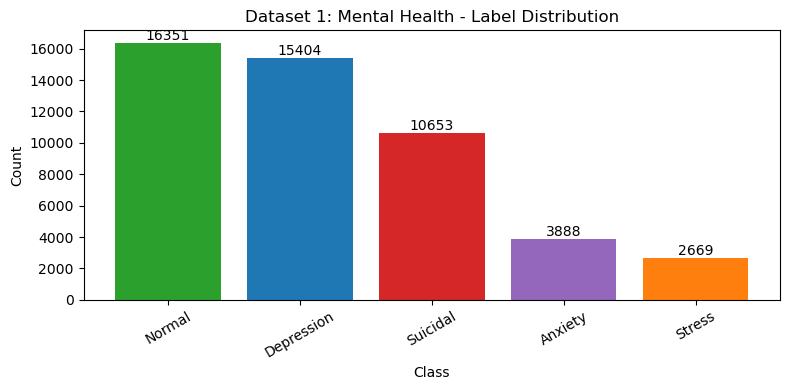

In [112]:
mh_df = pd.read_csv(MENTAL_HEALTH_PATH)
mh_df = mh_df.rename(columns={'statement': 'text', 'status': 'label', 'Mental Health Status': 'label'})
mh_df = mh_df[['text', 'label']].copy()
mh_df['label'] = mh_df['label'].str.strip()
mh_df = mh_df[mh_df['label'].isin(TARGET_CLASSES)]

print("Mental Health Dataset \n")
print("Total Nulls per column")
print(mh_df.isnull().sum())
print("")
print(mh_df['label'].value_counts())
print("")
explore_dataset('Dataset 1: Mental Health', mh_df)

Total Nulls per column
text     0
label    0
dtype: int64

Dataset 1: Mental Health After Cleaning
Shape: (39940, 2)
Text word count: min=10, max=6300, mean=130.9
Sample text: trouble sleeping, confused mind, restless heart. All out of tune



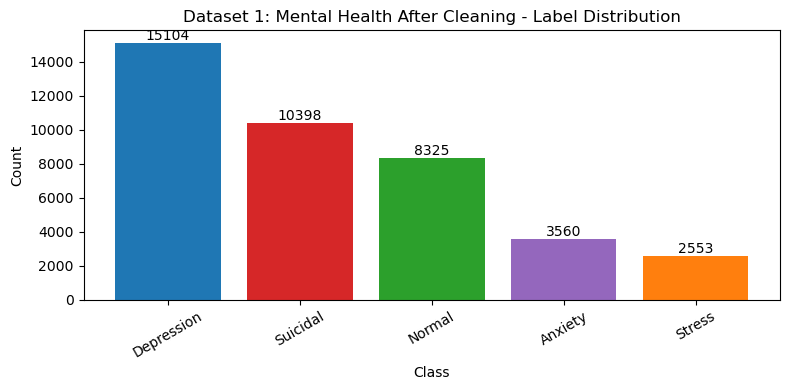

In [113]:
mh_df = quick_clean(mh_df)
print("Total Nulls per column")
print(mh_df.isnull().sum())
print("")
explore_dataset('Dataset 1: Mental Health After Cleaning', mh_df)

## SucideWatch Dataset

In [114]:
sw_df = pd.read_csv(SUICIDE_PATH)
sw_df.head(5)

,Unnamed: 0,text,class
0,2,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,3,Am I weird I don't get affected by compliments...,non-suicide
2,4,Finally 2020 is almost over... So I can never ...,non-suicide
3,8,i need helpjust help me im crying so hard,suicide
4,9,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


In [115]:
sw_df['class'].unique()

array(['suicide', 'non-suicide'], dtype=object)

SuicideWatch Dataset 

Total Nulls per column
Unnamed: 0    0
text          0
orig_label    0
label         0
dtype: int64

label
Suicidal    116037
Name: count, dtype: int64

Dataset 2: SuicideWatch
Shape: (116037, 4)
Text word count: min=1, max=9684, mean=202.7
Sample text: Ex Wife Threatening SuicideRecently I left my wife for good because she has cheated on me twice and lied to me so much that I have decided to refuse t



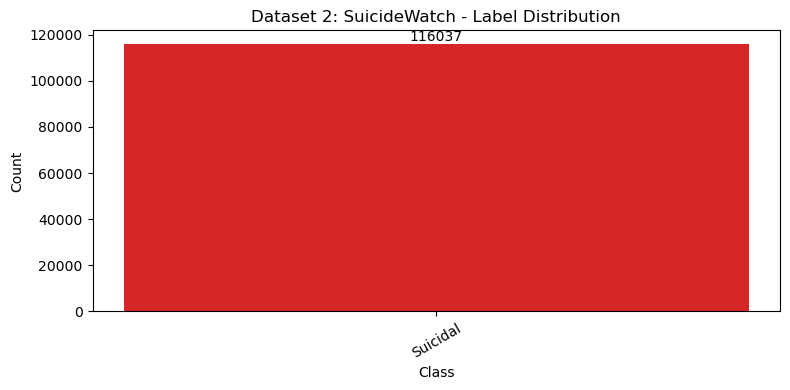

In [116]:
sw_df = pd.read_csv(SUICIDE_PATH)
sw_df = sw_df.rename(columns={'post': 'text', 'class': 'orig_label', 'label': 'orig_label'})
sw_df = sw_df[sw_df['orig_label'].str.lower().str.strip() == 'suicide']
sw_df['label'] = 'Suicidal'

print("SuicideWatch Dataset \n")
print("Total Nulls per column")
print(sw_df.isnull().sum())
print("")
print(sw_df['label'].value_counts())
print("")
explore_dataset('Dataset 2: SuicideWatch', sw_df)


Dataset 2: SuicideWatch after Cleaning and Sampling
Shape: (9602, 2)
Text word count: min=10, max=4532, mean=205.9
Sample text: Pls don't question people hereIf someone is talking to u about their struggles and stuff here pls don't question the credibility of their story. There



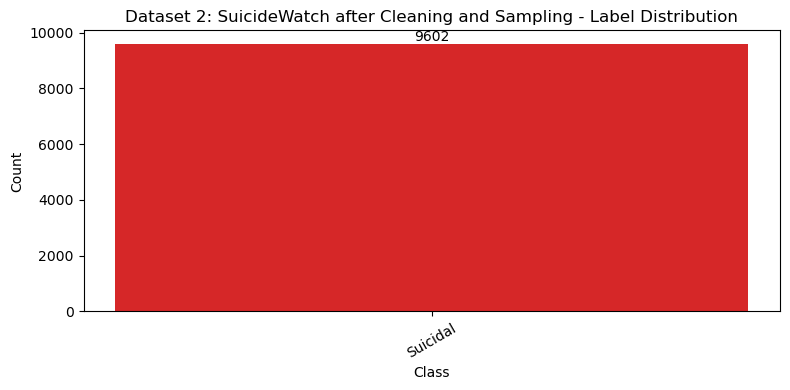

In [117]:
sw_df = quick_clean(sw_df) #Even though no null this is use to clean the text and filter out very short posts
sw_df = sw_df[['text', 'label']]

#Count how many suicidal are already in Mental Health dataset
mh_suicidal = len(mh_df[mh_df['label'] == 'Suicidal'])
sw_budget   = max(CAP_PER_CLASS - mh_suicidal, 0)

if len(sw_df) > sw_budget:
    sw_df = sw_df.sample(n=sw_budget, random_state=42)

explore_dataset('Dataset 2: SuicideWatch after Cleaning and Sampling', sw_df)

## Twitter Emotion Dataset

In [118]:
tw_train = pd.read_csv(TWITTER_TRAIN_PATH)
tw_val   = pd.read_csv(TWITTER_VAL_PATH)
tw_test  = pd.read_csv(TWITTER_TEST_PATH)
tw_df    = pd.concat([tw_train, tw_val, tw_test], ignore_index=True)

tw_df.head(5)

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [119]:
tw_df['label'].unique()

array([0, 3, 2, 5, 4, 1], dtype=int64)

Twitter Emotion Dataset 

Total Nulls per column
text     0
label    0
dtype: int64

label
Joy           8402
Depression    5797
Stress        2709
Anxiety       2373
Name: count, dtype: int64

Dataset 3: Twitter Emotion
Shape: (19281, 2)
Text word count: min=2, max=66, mean=19.1
Sample text: i didnt feel humiliated



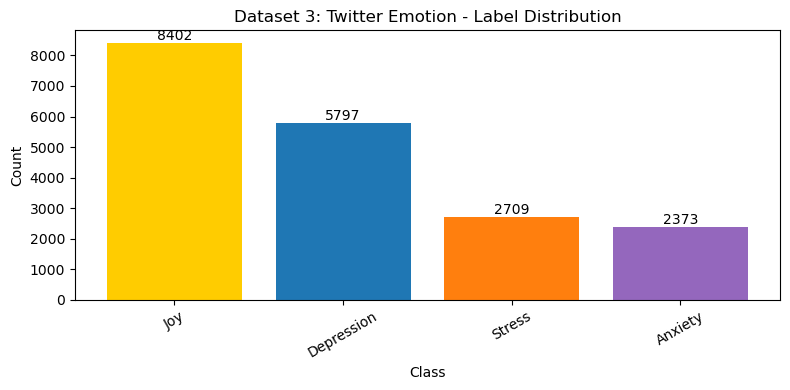

In [120]:
tw_train = pd.read_csv(TWITTER_TRAIN_PATH)
tw_val   = pd.read_csv(TWITTER_VAL_PATH)
tw_test  = pd.read_csv(TWITTER_TEST_PATH)
tw_df    = pd.concat([tw_train, tw_val, tw_test], ignore_index=True)

# 0=sadness=Depression, 1=Joy, 2=love=Joy, 3=anger=Stress, 4=fear=Anxiety, 5=surprise (drop)
TWITTER_LABEL_MAP = {0: 'Depression', 1: 'Joy', 2: 'Joy', 3: 'Stress', 4: 'Anxiety', 5: None}
tw_df['label'] = tw_df['label'].map(TWITTER_LABEL_MAP)

# Drop rows without valid label
tw_df = tw_df.dropna(subset=['label'])
tw_df = tw_df[['text', 'label']].copy()

print("Twitter Emotion Dataset \n")
print("Total Nulls per column")
print(tw_df.isnull().sum())
print("")
print(tw_df['label'].value_counts())
print("")

explore_dataset('Dataset 3: Twitter Emotion', tw_df)

After Cleaning 

Total Nulls per column
text     0
label    0
dtype: int64

label
Joy           6913
Depression    4417
Stress        2116
Anxiety       1846
Name: count, dtype: int64

Dataset 3: Twitter Emotion After Cleaning
Shape: (15292, 2)
Text word count: min=10, max=66, mean=22.3
Sample text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake



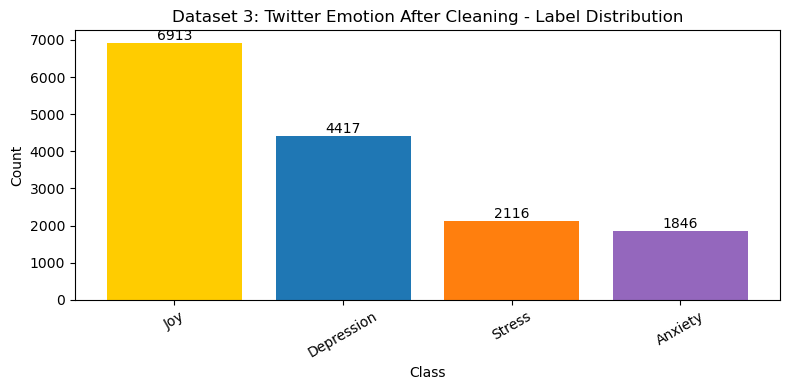

In [121]:
tw_df = quick_clean(tw_df)

print("After Cleaning \n")
print("Total Nulls per column")
print(tw_df.isnull().sum())
print("")
print(tw_df['label'].value_counts())
print("")

explore_dataset('Dataset 3: Twitter Emotion After Cleaning', tw_df)

## Emotions NLP Dataset

In [122]:
em_train = pd.read_csv(EMOTIONS_TRAIN_PATH, sep=';', header=None, names=['text', 'label'])
em_val = pd.read_csv(EMOTIONS_VAL_PATH, sep=';', header=None, names=['text', 'label'])
em_test = pd.read_csv(EMOTIONS_TEST_PATH, sep=';', header=None, names=['text', 'label'])
em_df = pd.concat([em_train, em_val, em_test], ignore_index=True)

em_df.head(5)

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [123]:
em_df['label'].unique()

array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
      dtype=object)

Emotions NLP Dataset 

Total Nulls per column
text     0
label    0
dtype: int64

Dataset 4: Emotions NLP (Joy)
Shape: (6761, 2)
Text word count: min=2, max=64, mean=19.4
Sample text: i have been with petronas for years i feel that petronas has performed well and made a huge profit



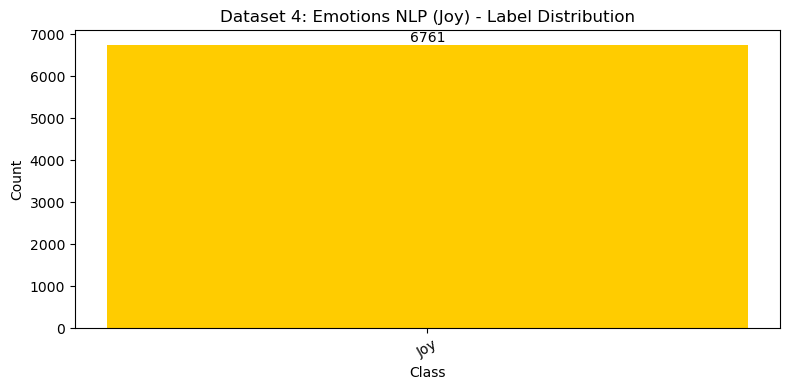

In [124]:
em_df = em_df[em_df['label'] == 'joy'].copy()
em_df['label'] = 'Joy'

print("Emotions NLP Dataset \n")
print("Total Nulls per column")
print(em_df.isnull().sum())
print("")

explore_dataset('Dataset 4: Emotions NLP (Joy)', em_df)


Dataset 4: Emotions NLP (Joy) After Cleaning
Shape: (5506, 2)
Text word count: min=10, max=64, mean=22.3
Sample text: i have been with petronas for years i feel that petronas has performed well and made a huge profit



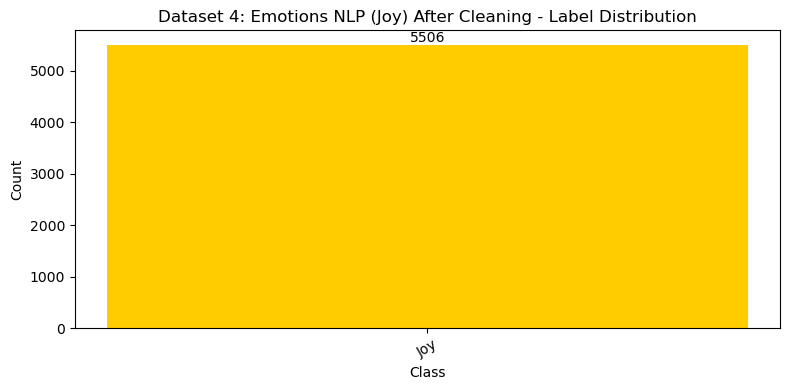

In [125]:
em_df = quick_clean(em_df) #Even though no null , this is use to clean the text and filter out very short posts
explore_dataset('Dataset 4: Emotions NLP (Joy) After Cleaning', em_df)

## Kaggle Emotions Dataset

In [126]:
emotions_df = pd.read_csv(EMOTIONS_CSV_PATH)
emotions_df.head(5)

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


In [127]:
emotions_df['label'].unique()

array([4, 0, 2, 1, 5, 3], dtype=int64)

In [128]:
EMOTIONS_LABEL_MAP = {0: 'Depression', 1: 'Joy', 2: None, 3: 'Stress', 4: 'Anxiety', 5: None}

C:\Users\rivin\AppData\Local\Temp\ipykernel_10876\2797595707.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  emotions_df = (emotions_df.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), caps.get(x.name, len(x))), random_state=42)))


Kaggle Emotions Dataset 

Total Nulls per column
text     0
label    0
dtype: int64

Dataset 5: Kaggle Emotions
Shape: (75000, 2)
Text word count: min=1, max=110, mean=19.0
Sample text: i feel that it creates a suspicious environment where every american is suspect who doesnt goose step to the majority party in power



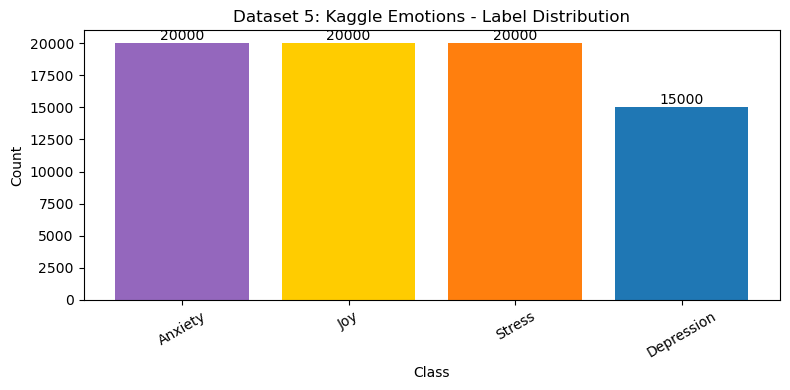

In [129]:
MAX_EMOTIONS_PER_CLASS = 20000
SADNESS_CAP            = 15000
emotions_df = emotions_df[['text', 'label']].copy()
emotions_df['label'] = emotions_df['label'].map(EMOTIONS_LABEL_MAP)
emotions_df = emotions_df.dropna(subset=['label'])
caps = {
    'Depression': SADNESS_CAP,
    'Joy':        MAX_EMOTIONS_PER_CLASS,
    'Stress':     MAX_EMOTIONS_PER_CLASS,
    'Anxiety':    MAX_EMOTIONS_PER_CLASS
}
emotions_df = (emotions_df.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), caps.get(x.name, len(x))), random_state=42)))

print("Kaggle Emotions Dataset \n")
print("Total Nulls per column")
print(emotions_df.isnull().sum())
print("")

explore_dataset('Dataset 5: Kaggle Emotions', emotions_df)

Dataset 5: Kaggle Emotions After Cleaning
Shape: (59246, 2)
Text word count: min=10, max=110, mean=22.3
Sample text: i feel that it creates a suspicious environment where every american is suspect who doesnt goose step to the majority party in power



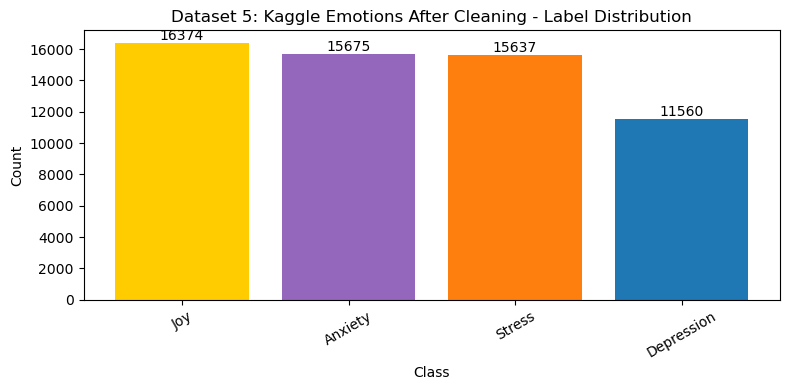

In [130]:

emotions_df = quick_clean(emotions_df) #Even though no null , this is use to clean the text and filter out very short posts
explore_dataset('Dataset 5: Kaggle Emotions After Cleaning', emotions_df)

## DailyDialog Dataset


In [131]:
daily_df = pd.read_csv(DAILYDIALOG_PATH)
daily_df.head(5)


,text,sentiment
0,I experienced this emotion when my grandfather...,sadness
1,"when I first moved in , I walked everywhere ....",neutral
2,"` Oh ! "" she bleated , her voice high and rath...",anger
3,"However , does the right hon. Gentleman recogn...",fear
4,My boyfriend didn't turn up after promising th...,sadness


In [132]:
daily_df['sentiment'].unique()

array(['sadness', 'neutral', 'anger', 'fear', 'joy'], dtype=object)

DailyDialog Dataset 

Total Nulls per column
text     0
label    0
dtype: int64

Dataset 6 DailyDialog Dataset
Shape: (5506, 2)
Text word count: min=10, max=64, mean=22.3
Sample text: i have been with petronas for years i feel that petronas has performed well and made a huge profit



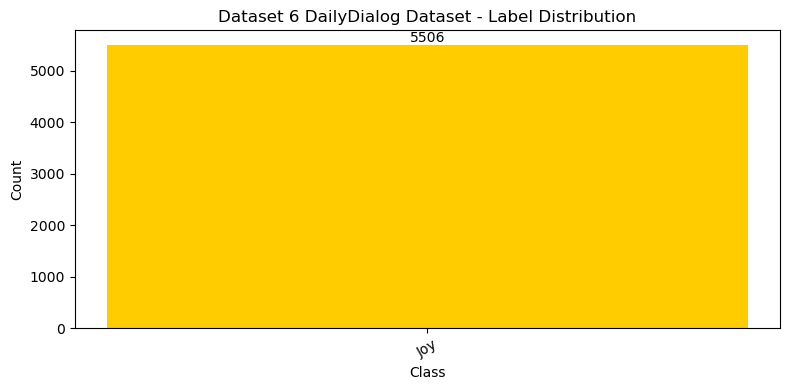

In [133]:
daily_df = daily_df.rename(columns={'sentiment': 'orig_label'})

daily_df['label'] = daily_df['orig_label'].astype(str).str.lower().str.strip()
daily_df = daily_df[daily_df['label'] == 'neutral']
daily_df['label'] = 'Normal'

print("DailyDialog Dataset \n")
print("Total Nulls per column")
print(em_df.isnull().sum())
print("")

explore_dataset('Dataset 6 DailyDialog Dataset', em_df)

Dataset 6 DailyDialog (Normal) After Cleaning
Shape: (511, 3)
Text word count: min=10, max=101, mean=19.4
Sample text: when I first moved in , I walked everywhere . But within a week , I had my purse stolen — just a block away from the police station ! Now , I always t



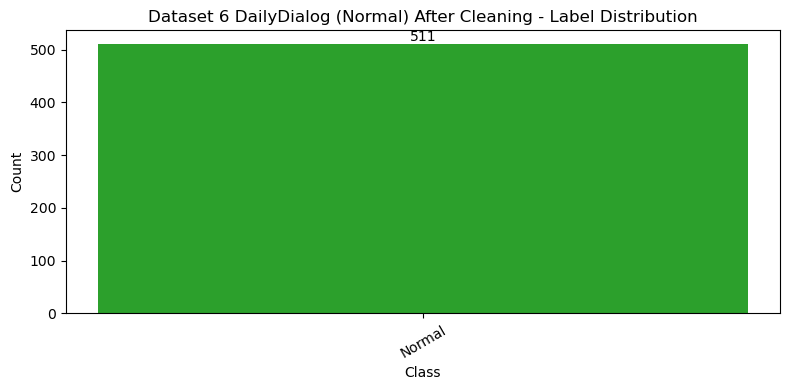

In [134]:
daily_df = quick_clean(daily_df)
daily_df = daily_df.drop_duplicates(subset=['text'])
explore_dataset('Dataset 6 DailyDialog (Normal) After Cleaning', daily_df)

## Emotion Dataset V5

In [135]:
emotion_v5_df = pd.read_csv(EMOTION_V5_PATH)
emotion_v5_df.head(5)


,sentence,emotion,cleaned_text
0,I'm so furious with you right now.,anger,i'm so furious with you right now.
1,My day is ruined because of this crap.,anger,my day is ruined because of this crap.
2,I feel like I'm about to explode.,anger,i feel like i'm about to explode.
3,This is the worst day of my life.,anger,this is the worst day of my life.
4,I hate everything about this situation.,anger,i hate everything about this situation.


In [136]:
emotion_v5_df['emotion'].unique()

array(['anger', 'anxiety', 'confusion', 'disappointment', 'disgust',
       'embarrassment', 'excitement', 'fear', 'frustration', 'gratitude',
       'guilt', 'happiness', 'hope', 'jealousy', 'loneliness', 'love',
       'pride', 'relief', 'sadness', 'surprise'], dtype=object)

Emotion Dataset V5 

Total Nulls per column
text          0
orig_label    0
label         0
dtype: int64

Dataset 7 Emotion Dataset V5
Shape: (75533, 3)
Text word count: min=3, max=10, mean=8.7
Sample text: i'm so furious with you right now.



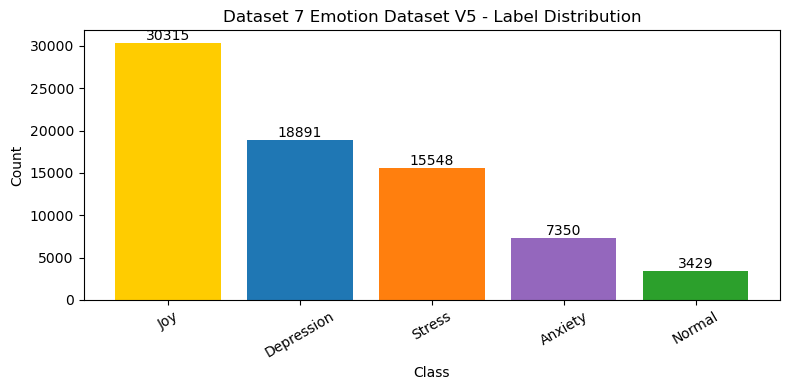

In [137]:
EMOTION_V5_MAP = {
    'happiness':'Joy','gratitude':'Joy','love':'Joy','excitement':'Joy',
    'hope':'Joy','pride':'Joy','relief':'Joy',
    'anger':'Stress','frustration':'Stress','disgust':'Stress','jealousy':'Stress',
    'anxiety':'Anxiety','fear':'Anxiety',
    'sadness':'Depression','loneliness':'Depression','disappointment':'Depression',
    'guilt':'Depression','embarrassment':'Depression',
    'confusion':'Normal','surprise': None
}
EMOTION_V5_CAPS = {'Joy': 5000, 'Stress': 5000, 'Anxiety': 4000, 'Depression': 5000}

text_col  = 'cleaned_text'
label_col = 'emotion'
emotion_v5_df = emotion_v5_df[[text_col, label_col]].rename(
    columns={text_col: 'text', label_col: 'orig_label'}
)
emotion_v5_df['label'] = emotion_v5_df['orig_label'].astype(str).str.lower().str.strip().map(EMOTION_V5_MAP)
emotion_v5_df = emotion_v5_df.dropna(subset=['label'])

print("Emotion Dataset V5 \n")
print("Total Nulls per column")
print(emotion_v5_df.isnull().sum())
print("")

explore_dataset('Dataset 7 Emotion Dataset V5', emotion_v5_df)

Dataset 7: Emotion V5
Shape: (12928, 3)
Text word count: min=10, max=10, mean=10.0
Sample text: my anxiety is creeping in and it's hard to focus.



C:\Users\rivin\AppData\Local\Temp\ipykernel_10876\3400950995.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), EMOTION_V5_CAPS.get(x.name, len(x))), random_state=42)))


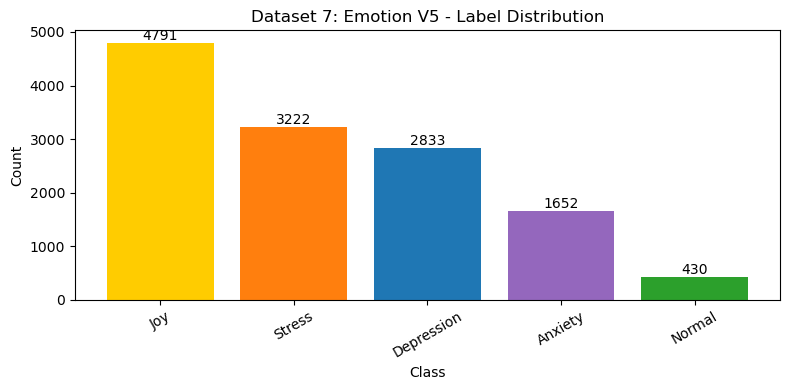

In [138]:
emotion_v5_df = emotion_v5_df.dropna(subset=['text', 'label'])
emotion_v5_df = quick_clean(emotion_v5_df)
emotion_v5_df = (emotion_v5_df.groupby('label', group_keys=False)
                 .apply(lambda x: x.sample(min(len(x), EMOTION_V5_CAPS.get(x.name, len(x))), random_state=42)))
emotion_v5_df = emotion_v5_df.drop_duplicates(subset=['text'])
explore_dataset('Dataset 7: Emotion V5', emotion_v5_df)

## Feature Engineered Dataset

In [139]:
fe_df = pd.read_csv(FEATURE_ENGINEERED_PATH)
fe_df.head(5)


,Unique_ID,text,status,text_length,word_count,num_urls,num_emojis,num_special_chars,num_excess_punct,avg_word_length,...,type_token_ratio,polarity,subjectivity,noun_ratio,verb_ratio,adj_ratio,adv_ratio,has_suicidal_keyword,has_stress_keyword,has_help_keyword
0,0.0,oh my gosh,Anxiety,0.001678,0.007576,0.0,0.0,0.0,0.0,0.005395,...,1.000000,0.50000,0.0000,0.0,0.000000,0.333333,0.0,False,False,False
1,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety,0.046980,0.034091,0.0,0.0,0.0,0.0,0.015152,...,1.000000,0.35000,0.4500,0.0,0.100000,0.000000,0.0,False,False,False
2,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,0.058725,0.049242,0.0,0.0,0.0,0.0,0.012200,...,0.926576,0.37500,0.4500,0.0,0.000000,0.071429,0.0,False,False,False
3,3.0,I've shifted my focus to something else but I'...,Anxiety,0.044463,0.037879,0.0,0.0,0.0,0.0,0.012178,...,1.000000,0.50000,0.0000,0.0,0.272727,0.090909,0.0,False,False,False
4,4.0,"I'm restless and restless, it's been a month n...",Anxiety,0.053691,0.049242,0.0,0.0,0.0,0.0,0.010724,...,1.000000,0.34375,0.6875,0.0,0.000000,0.000000,0.0,False,False,False


In [140]:
fe_df['status'].unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal'], dtype=object)

Feature Engineered Dataset 

Total Nulls per column
Unique_ID               9600
text                       0
orig_label                 0
text_length             9600
word_count              9600
num_urls                9600
num_emojis              9600
num_special_chars       9600
num_excess_punct        9600
avg_word_length         9600
stopword_ratio          9600
type_token_ratio        9600
polarity                9600
subjectivity            9600
noun_ratio              9600
verb_ratio              9600
adj_ratio               9600
adv_ratio               9600
has_suicidal_keyword    9600
has_stress_keyword      9600
has_help_keyword        9600
label                      0
dtype: int64

Dataset 8 Feature Engineered Dataset
Shape: (49612, 22)
Text word count: min=1, max=9684, mean=78.2
Sample text: oh my gosh



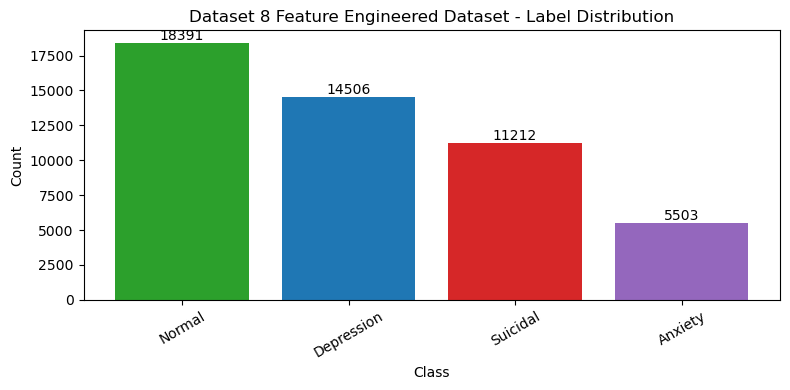

In [141]:
FE_CAPS = {'Suicidal': 8000, 'Depression': 5000, 'Anxiety': 8000}

fe_df = fe_df.rename(columns={'status': 'orig_label'})

fe_df['label'] = fe_df['orig_label'].astype(str).str.strip()

print("Feature Engineered Dataset \n")
print("Total Nulls per column")
print(fe_df.isnull().sum())
print("")

explore_dataset('Dataset 8 Feature Engineered Dataset', fe_df)

C:\Users\rivin\AppData\Local\Temp\ipykernel_10876\2670913279.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Dataset 9 Feature Engineered
Shape: (28592, 22)
Text word count: min=10, max=6353, mean=86.4
Sample text: When the swaddle is gone, hand & her legs look restless & nervous



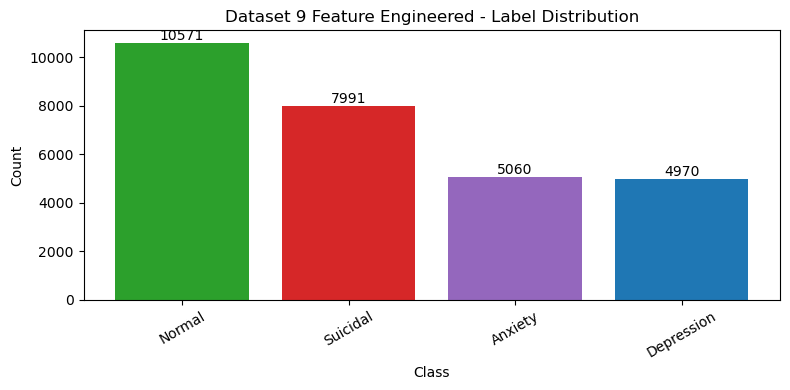

In [142]:
fe_df = fe_df.dropna(subset=['text', 'label'])
fe_df = quick_clean(fe_df)
fe_df = (fe_df.groupby('label', group_keys=False)
         .apply(lambda x: x.sample(
             min(len(x), FE_CAPS.get(x.name, len(x))), random_state=42)))
fe_df = fe_df.drop_duplicates(subset=['text'])
explore_dataset('Dataset 9 Feature Engineered', fe_df)

## Cancer Vocab Dataset

In [143]:
cancer_df = pd.read_csv(CANCER_PATH)
cancer_df.head(5)

,posts,predicted,intensity
0,I know as parent of child with down syndrome t...,negative,-1
1,but in my heart I know this is the future prom...,neutral,0
2,I have mylefibrosis which turn to leukemia the...,negative,-1
3,from one of my health group subject wayne dyer...,neutral,0
4,gmos now link to leukemia http nsnbc I 2013 07...,neutral,0


In [144]:
cancer_df = cancer_df.rename(columns={'posts': 'text'})
cancer_df = cancer_df[['text']].copy()

print("Cancer Vocab Dataset \n")
print("Total Nulls per column")
print(cancer_df.isnull().sum())
print("")

explore_dataset('Dataset 10 Cancer Vocab', cancer_df, has_labels=False)

Cancer Vocab Dataset 

Total Nulls per column
text    1
dtype: int64

Dataset 10 Cancer Vocab
Shape: (10392, 1)
Text word count: min=1.0, max=5413.0, mean=234.1
Sample text: I know as parent of child with down syndrome that you have all hear that our child are at a high risk of leukemia as parent we read up on it and then 



In [145]:
cancer_df = quick_clean(cancer_df)
cancer_df['text'] = cancer_df['text'].str.replace(r'http\S+', '', regex=True).str.strip()
cancer_df = cancer_df.drop_duplicates(subset=['text'])
explore_dataset('Dataset 10 Cancer Vocab After Cleaning', cancer_df, has_labels=False)

Dataset 10 Cancer Vocab After Cleaning
Shape: (10274, 1)
Text word count: min=10, max=5413, mean=236.7
Sample text: I know as parent of child with down syndrome that you have all hear that our child are at a high risk of leukemia as parent we read up on it and then 



# Combine Datasets

In [146]:
combined_df = pd.concat([mh_df, sw_df, tw_df, em_df, emotions_df, daily_df, emotion_v5_df, fe_df], ignore_index=True)
combined_df.head(5)

,text,label,orig_label,Unique_ID,text_length,word_count,num_urls,num_emojis,num_special_chars,num_excess_punct,...,type_token_ratio,polarity,subjectivity,noun_ratio,verb_ratio,adj_ratio,adv_ratio,has_suicidal_keyword,has_stress_keyword,has_help_keyword
0,"trouble sleeping, confused mind, restless hear...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,I've shifted my focus to something else but I'...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"I'm restless and restless, it's been a month n...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"every break, you must be nervous, like somethi...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [147]:
combined_df['label'].unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress', 'Joy'],
      dtype=object)

After concat : 171,617 rows
After dedup: 140,309 rows (removed 31,308 duplicates)

After Joy to Normal merge (before cap):
  Normal        38,711
  Depression    33,802
  Anxiety       24,075
  Stress        22,145
  Suicidal      21,576


C:\Users\rivin\AppData\Local\Temp\ipykernel_10876\483837430.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), CAP_PER_CLASS), random_state=42))



After capping at 20,000 per class:
  Stress        20,000  (20.0%)
  Suicidal      20,000  (20.0%)
  Anxiety       20,000  (20.0%)
  Normal        20,000  (20.0%)
  Depression    20,000  (20.0%)
Combined Dataset
Shape: (100000, 2)
Text word count: min=10, max=6353, mean=75.5
Sample text: i didn't know they were that close with him too



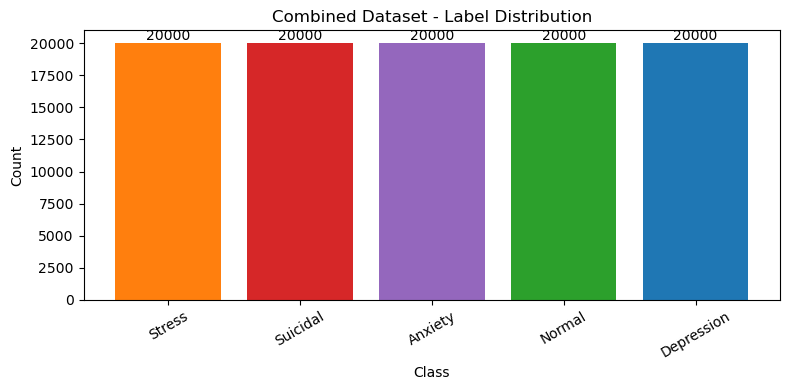

In [148]:
combined_df = pd.concat([mh_df, sw_df, tw_df, em_df, emotions_df, daily_df, emotion_v5_df, fe_df], ignore_index=True)

print(f'After concat : {len(combined_df):,} rows')

before_dedup = len(combined_df)
combined_df = combined_df.drop_duplicates(subset=['text'])
print(f'After dedup: {len(combined_df):,} rows (removed {before_dedup - len(combined_df):,} duplicates)')

# Merge Joy to normal before capping so normal doesnt get too big (after examining joy emotion is very similar to a person in normal therefore decided to combine them)
combined_df['label'] = combined_df['label'].replace('Joy', 'Normal')
print(f'\nAfter Joy to Normal merge (before cap):')
pre_cap = combined_df['label'].value_counts()
for label, count in pre_cap.items():
    print(f'  {label:<12} {count:>7,}')

# Cap all classes so that Normal in check after the merge
combined_df = (
    combined_df.groupby('label', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), CAP_PER_CLASS), random_state=42))
)

combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)
combined_df = combined_df[['text', 'label']]

print(f'\nAfter capping at {CAP_PER_CLASS:,} per class:')
class_dist = combined_df['label'].value_counts()
for label, count in class_dist.items():
    pct = count / len(combined_df) * 100
    print(f'  {label:<12} {count:>7,}  ({pct:.1f}%)')
    
explore_dataset('Combined Dataset', combined_df)

In [149]:
print(f'Combined dataset: {combined_df.shape[0]:,} rows, {combined_df.shape[1]} columns')
print(f"Duplicates removed: {before_dedup - len(combined_df):,}")
print(f'Missing values: {combined_df.isnull().sum().sum()}')
print()

class_dist = combined_df['label'].value_counts()
print('Class distribution:')
for label, count in class_dist.items():
    pct = count / len(combined_df) * 100
    print(f'  {label:<12} {count:>7,}  ({pct:.1f}%)')

print()
largest = class_dist.iloc[0]
smallest = class_dist.iloc[-1]
ratio = largest / smallest
print(f'Imbalance ratio (largest/smallest): {ratio:.1f}x ({class_dist.index[0]} vs {class_dist.index[-1]})')

Combined dataset: 100,000 rows, 2 columns
Duplicates removed: 71,617
Missing values: 0

Class distribution:
  Stress        20,000  (20.0%)
  Suicidal      20,000  (20.0%)
  Anxiety       20,000  (20.0%)
  Normal        20,000  (20.0%)
  Depression    20,000  (20.0%)

Imbalance ratio (largest/smallest): 1.0x (Stress vs Depression)


In [150]:
combined_df.to_csv(OUTPUT_LABELED_PATH, index=False, encoding='utf-8')
cancer_df[['text']].to_csv(OUTPUT_VOCAB_PATH, index=False, encoding='utf-8')

print('Datasets saved')


Datasets saved


## Preprocessing 

In [151]:
print('Preprocessing text')
df = combined_df.copy()

df['num_chars'] = df['text'].str.len()
df['num_sentences'] = df['text'].apply(lambda x: len(sent_tokenize(str(x))))
df['num_words'] = df['text'].str.split().str.len()
df['clean_text'] = df['text'].apply(remove_patterns).apply(lemmatize_text)

print('Before vs After:')
for i in range(3):
    print(f'Original: {df["text"].iloc[i][:80]}')
    print(f'Cleaned: {df["clean_text"].iloc[i][:80]}')
    print()

Preprocessing text
Before vs After:
Original: i didn't know they were that close with him too
Cleaned: i didnt know they be that close with him too

Original: Im 17. If my life doesnt get better by the time i turn 18 or next year, im gonna
Cleaned: im if my life doesnt get well by the time i turn or next year im gon na shoot my

Original: i am feeling slightly petrified about all of the changes to come and so is she
Cleaned: i be feel slightly petrify about all of the change to come and so be she

